In [1]:
## 1. Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


In [12]:
#df = pd.read_csv('/content/base_modelo_preditivo.csv')

df = pd.read_csv('/content/base_vendas_ficticia.csv', sep = ';')
df.head(10)

,id_pedido,data_pedido,ano,mes,ano_mes,cliente,vendedor,regiao,categoria,produto,canal,status_pedido,quantidade,receita_bruta,receita_liquida,custo,lucro
0,1,2025-04-13,2025,4,2025-04,Cliente 215,Vendedor 11,Nordeste,Escritório,Agenda,Loja Física,Concluído,8,983.80,983.80,790.40,193.41
1,2,2025-07-11,2025,7,2025-07,Cliente 49,Vendedor 10,Norte,Tecnologia,Mouse,Loja Física,Concluído,3,5700.62,5700.62,3828.73,1871.88
2,3,2025-10-01,2025,10,2025-10,Cliente 53,Vendedor 2,Norte,Serviços,Suporte Técnico,Representante,Concluído,4,23756.35,23756.35,15574.34,8182.01
3,4,2025-02-19,2025,2,2025-02,Cliente 191,Vendedor 18,Nordeste,Móveis,Cadeira,Loja Física,Concluído,10,10479.61,10479.61,7377.85,3101.76
4,5,2025-09-09,2025,9,2025-09,Cliente 280,Vendedor 13,Sudeste,Suprimentos,Filtro de Linha,Representante,Concluído,9,3427.00,3427.00,2156.41,1270.59
5,6,2025-03-04,2025,3,2025-03,Cliente 231,Vendedor 9,Centro-Oeste,Tecnologia,Teclado,Representante,Concluído,7,28662.68,28662.68,20918.00,7744.68
6,7,2025-06-21,2025,6,2025-06,Cliente 131,Vendedor 1,Sul,Escritório,Pasta,Loja Física,Concluído,5,519.11,519.11,289.07,230.03
7,8,2025-06-28,2025,6,2025-06,Cliente 231,Vendedor 13,Sudeste,Tecnologia,Mouse,Loja Física,Concluído,4,20843.36,20843.36,13127.59,7715.77
8,9,2025-05-14,2025,5,2025-05,Cliente 231,Vendedor 1,Sul,Serviços,Suporte Técnico,Representante,Concluído,1,6955.48,6955.48,4784.69,2170.79
9,10,2025-05-17,2025,5,2025-05,Cliente 160,Vendedor 9,Sul,Tecnologia,Teclado,Online,Concluído,4,8290.78,8290.78,5233.45,3057.33


In [13]:
base_vendas = df.copy()

In [14]:
base_vendas.head(3)

,id_pedido,data_pedido,ano,mes,ano_mes,cliente,vendedor,regiao,categoria,produto,canal,status_pedido,quantidade,receita_bruta,receita_liquida,custo,lucro
0,1,2025-04-13,2025,4,2025-04,Cliente 215,Vendedor 11,Nordeste,Escritório,Agenda,Loja Física,Concluído,8,983.80,983.80,790.40,193.41
1,2,2025-07-11,2025,7,2025-07,Cliente 49,Vendedor 10,Norte,Tecnologia,Mouse,Loja Física,Concluído,3,5700.62,5700.62,3828.73,1871.88
2,3,2025-10-01,2025,10,2025-10,Cliente 53,Vendedor 2,Norte,Serviços,Suporte Técnico,Representante,Concluído,4,23756.35,23756.35,15574.34,8182.01


In [15]:


## 3. Verificação inicial dos dados

print("Quantidade de linhas:", base_vendas.shape[0])
print("Quantidade de colunas:", base_vendas.shape[1])

print("\nTipos das variáveis:")
print(base_vendas.dtypes)

print("\nValores ausentes:")
print(base_vendas.isna().sum())



Quantidade de linhas: 2500
Quantidade de colunas: 17

Tipos das variáveis:
id_pedido            int64
data_pedido         object
ano                  int64
mes                  int64
ano_mes             object
cliente             object
vendedor            object
regiao              object
categoria           object
produto             object
canal               object
status_pedido       object
quantidade           int64
receita_bruta      float64
receita_liquida    float64
custo              float64
lucro              float64
dtype: object

Valores ausentes:
id_pedido          0
data_pedido        0
ano                0
mes                0
ano_mes            0
cliente            0
vendedor           0
regiao             0
categoria          0
produto            0
canal              0
status_pedido      0
quantidade         0
receita_bruta      0
receita_liquida    0
custo              0
lucro              0
dtype: int64


In [17]:
base_vendas.columns

Index(['id_pedido', 'data_pedido', 'ano', 'mes', 'ano_mes', 'cliente',
       'vendedor', 'regiao', 'categoria', 'produto', 'canal', 'status_pedido',
       'quantidade', 'receita_bruta', 'receita_liquida', 'custo', 'lucro'],
      dtype='object')


## 4. Criação da variável alvo

A variável `pedido_concluido` terá os seguintes valores:

1 para pedidos concluídos.

0 para pedidos cancelados ou devolvidos.


In [18]:

base_vendas["pedido_concluido"] = np.where(
    base_vendas["status_pedido"] == "Concluído",
    1,
    0
)

print(base_vendas["pedido_concluido"].value_counts())

print("\nPercentual por classe:")
print(
    base_vendas["pedido_concluido"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


pedido_concluido
1    2207
0     293
Name: count, dtype: int64

Percentual por classe:
pedido_concluido
1    88.28
0    11.72
Name: proportion, dtype: float64



## 5. Seleção das variáveis do modelo

Serão usadas apenas informações disponíveis antes da conclusão do pedido.

As variáveis `receita_liquida`, `custo` e `lucro` não serão utilizadas, pois seus valores dependem do status final do pedido.



In [22]:
variaveis_modelo = [
    "mes",
    "regiao",
    "categoria",
    "produto",
    "canal",
    "vendedor",
    "quantidade",
    "receita_bruta"
]

variavel_alvo = "pedido_concluido"

dados_entrada = base_vendas[variaveis_modelo]
dados_alvo = base_vendas[variavel_alvo]


## 6. Separação entre treino e teste

A divisão estratificada mantém a proporção das classes nas duas bases.

(
    dados_entrada_treino,
    dados_entrada_teste,
    dados_alvo_treino,
    dados_alvo_teste
) = train_test_split(
    dados_entrada,
    dados_alvo,
    test_size=0.30,
    random_state=42,
    stratify=dados_alvo
)


In [32]:

## 6. Separação entre treino e teste


(
    dados_entrada_treino,
    dados_entrada_teste,
    dados_alvo_treino,
    dados_alvo_teste
) = train_test_split(
    dados_entrada,
    dados_alvo,
    test_size=0.30,
    random_state=42,
    stratify=dados_alvo
)

print("Linhas de treino:", dados_entrada_treino.shape[0])
print("Linhas de teste:", dados_entrada_teste.shape[0])



Linhas de treino: 1750
Linhas de teste: 750


In [29]:


## 7. Separação das variáveis numéricas e categóricas

variaveis_numericas = [
    "mes",
    "quantidade",
    "receita_bruta"
]

variaveis_categoricas = [
    "regiao",
    "categoria",
    "produto",
    "canal",
    "vendedor"
]



In [33]:


## 8. Preparação dos dados

#===================== padronizandoo
#As variáveis numéricas serão padronizadas.

#s variáveis categóricas serão transformadas em colunas numéricas com One Hot Encoding.


tratamento_numerico = Pipeline(
    steps=[
        ("padronizacao", StandardScaler())
    ]
)

tratamento_categorico = Pipeline(
    steps=[
        (
            "codificacao",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preparador_dados = ColumnTransformer(
    transformers=[
        (
            "numericas",
            tratamento_numerico,
            variaveis_numericas
        ),
        (
            "categoricas",
            tratamento_categorico,
            variaveis_categoricas
        )
    ]
)




## 9. Criação do modelo

O parâmetro `class_weight="balanced"` reduz o impacto do desbalanceamento entre pedidos concluídos e não concluídos.


In [34]:

 modelo_logistico = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

pipeline_modelo = Pipeline(
    steps=[
        ("preparacao", preparador_dados),
        ("modelo", modelo_logistico)
    ]
)


## 10. Treinamento do modelo

pipeline_modelo.fit(
    dados_entrada_treino,
    dados_alvo_treino
)

print("Modelo treinado com sucesso.")


## 11. Geração das previsões


previsao_classe = pipeline_modelo.predict(
    dados_entrada_teste
)

previsao_probabilidade = pipeline_modelo.predict_proba(
    dados_entrada_teste
)[:, 1]



Modelo treinado com sucesso.


In [35]:

## 12. Avaliação do modelo


acuracia = accuracy_score(
    dados_alvo_teste,
    previsao_classe
)

precisao = precision_score(
    dados_alvo_teste,
    previsao_classe
)

recall = recall_score(
    dados_alvo_teste,
    previsao_classe
)

f1 = f1_score(
    dados_alvo_teste,
    previsao_classe
)

auc = roc_auc_score(
    dados_alvo_teste,
    previsao_probabilidade
)

print("Acurácia:", round(acuracia, 4))
print("Precisão:", round(precisao, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC AUC:", round(auc, 4))


## 13. Relatório de classificação


print(
    classification_report(
        dados_alvo_teste,
        previsao_classe,
        target_names=[
            "Cancelado ou devolvido",
            "Concluído"
        ]
    )
)



Acurácia: 0.5267
Precisão: 0.8771
Recall: 0.5393
F1-score: 0.6679
ROC AUC: 0.4876
                        precision    recall  f1-score   support

Cancelado ou devolvido       0.11      0.43      0.18        88
             Concluído       0.88      0.54      0.67       662

              accuracy                           0.53       750
             macro avg       0.49      0.49      0.42       750
          weighted avg       0.79      0.53      0.61       750



In [ ]:

## 14. Matriz de confusão


ConfusionMatrixDisplay.from_predictions(
    dados_alvo_teste,
    previsao_classe,
    display_labels=[
        "Não concluído",
        "Concluído"
    ]
)

plt.title("Matriz de confusão")
plt.show()


## 15. Curva ROC


RocCurveDisplay.from_predictions(
    dados_alvo_teste,
    previsao_probabilidade
)

plt.title("Curva ROC")
plt.show()



## 16. Geração do risco de não conclusão

A probabilidade retornada pelo modelo representa a chance de o pedido ser concluído.

O risco de não conclusão será calculado como:

Risco = 1 menos a probabilidade de conclusão.

In [36]:
base_resultado = dados_entrada_teste.copy()

base_resultado["resultado_real"] = dados_alvo_teste.values
base_resultado["previsao_modelo"] = previsao_classe
base_resultado["probabilidade_conclusao"] = previsao_probabilidade

base_resultado["risco_nao_conclusao"] = (
    1 - base_resultado["probabilidade_conclusao"]
)



In [38]:

## 17. Classificação do risco


def classificar_risco(probabilidade):
    if probabilidade >= 0.70:
        return "Alto"
    elif probabilidade >= 0.40:
        return "Médio"
    else:
        return "Baixo"


base_resultado["classificacao_risco"] = (
    base_resultado["risco_nao_conclusao"]
    .apply(classificar_risco)
)

base_resultado.head()

## 18. Inclusão do identificador e do status original

base_resultado = base_resultado.merge(
    base_vendas[
        [
            "id_pedido",
            "status_pedido"
        ]
    ],
    left_index=True,
    right_index=True,
    how="left"
)
 ## 19. Exportação para o Power BI

base_resultado.to_csv(
    "/content/base_risco_pedidos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo base_risco_pedidos.csv criado com sucesso.")



Arquivo base_risco_pedidos.csv criado com sucesso.


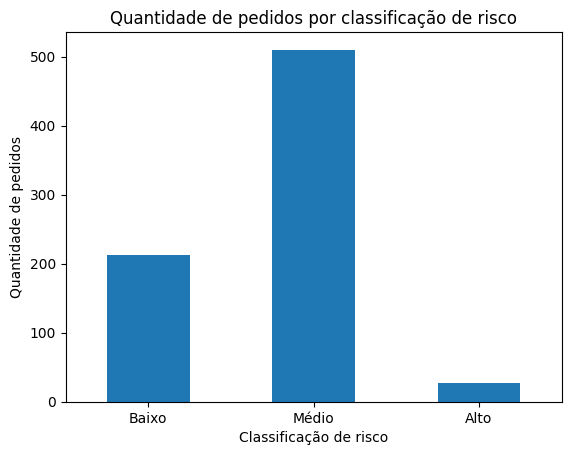

In [39]:



## 20. Distribuição das classificações de risco


quantidade_por_risco = (
    base_resultado["classificacao_risco"]
    .value_counts()
    .reindex(["Baixo", "Médio", "Alto"])
)

quantidade_por_risco.plot(
    kind="bar"
)

plt.title("Quantidade de pedidos por classificação de risco")
plt.xlabel("Classificação de risco")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=0)
plt.show()

## 21. Explicabilidade do modelo

Na Regressão Logística, os coeficientes ajudam a identificar quais variáveis aumentam ou reduzem a probabilidade de conclusão do pedido.

Coeficientes positivos aumentam a probabilidade de conclusão.

Coeficientes negativos reduzem a probabilidade de conclusão.



In [40]:


preparador_treinado = pipeline_modelo.named_steps["preparacao"]
modelo_treinado = pipeline_modelo.named_steps["modelo"]

nomes_variaveis = (
    preparador_treinado
    .get_feature_names_out()
)

coeficientes = modelo_treinado.coef_[0]

importancia_variaveis = pd.DataFrame({
    "variavel": nomes_variaveis,
    "coeficiente": coeficientes
})

importancia_variaveis["importancia_absoluta"] = (
    importancia_variaveis["coeficiente"].abs()
)

importancia_variaveis = (
    importancia_variaveis
    .sort_values(
        "importancia_absoluta",
        ascending=False
    )
)

importancia_variaveis.head(15)



,variavel,coeficiente,importancia_absoluta
34,categoricas__vendedor_Vendedor 11,1.221037,1.221037
43,categoricas__vendedor_Vendedor 2,0.912876,0.912876
23,categoricas__produto_Notebook,-0.770139,0.770139
41,categoricas__vendedor_Vendedor 18,0.767814,0.767814
42,categoricas__vendedor_Vendedor 19,0.750296,0.750296
19,categoricas__produto_Impressora,0.622257,0.622257
24,categoricas__produto_Papel A4,-0.616892,0.616892
49,categoricas__vendedor_Vendedor 7,0.588737,0.588737
46,categoricas__vendedor_Vendedor 4,0.562136,0.562136
38,categoricas__vendedor_Vendedor 15,0.547299,0.547299


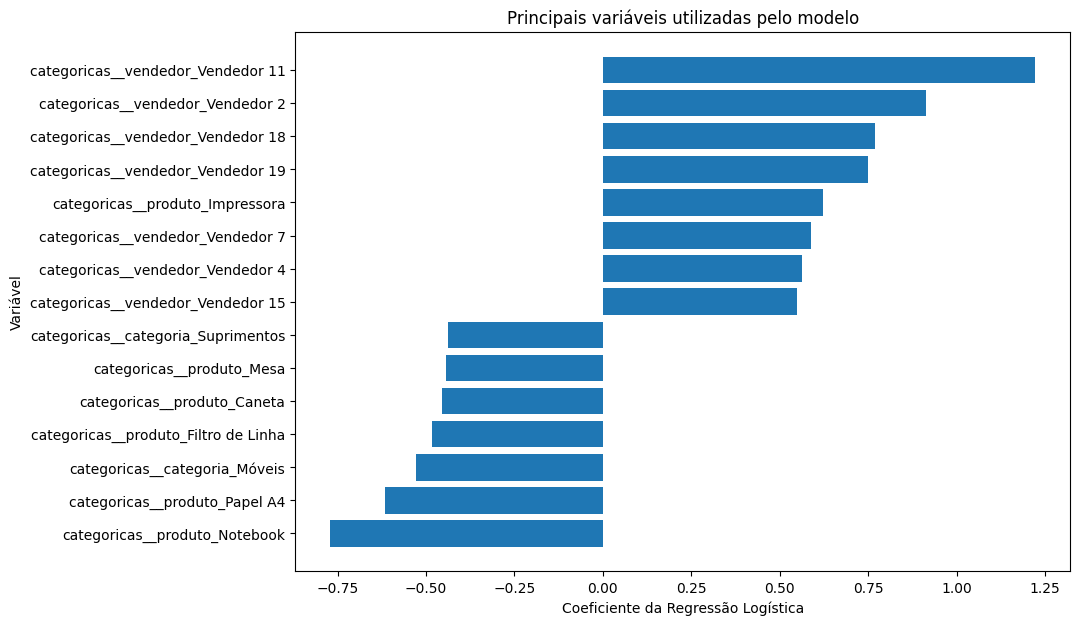

,variavel,coeficiente
23,categoricas__produto_Notebook,-0.770139
24,categoricas__produto_Papel A4,-0.616892
7,categoricas__categoria_Móveis,-0.528982
17,categoricas__produto_Filtro de Linha,-0.484354
14,categoricas__produto_Caneta,-0.455238
20,categoricas__produto_Mesa,-0.443824
9,categoricas__categoria_Suprimentos,-0.438822
8,categoricas__categoria_Serviços,-0.332533
10,categoricas__categoria_Tecnologia,-0.326536
26,categoricas__produto_Suporte Técnico,-0.314364


In [41]:

## 22. Gráfico das variáveis mais importantes


principais_variaveis = importancia_variaveis.head(15).copy()

principais_variaveis = principais_variaveis.sort_values(
    "coeficiente"
)

plt.figure(figsize=(10, 7))

plt.barh(
    principais_variaveis["variavel"],
    principais_variaveis["coeficiente"]
)

plt.title("Principais variáveis utilizadas pelo modelo")
plt.xlabel("Coeficiente da Regressão Logística")
plt.ylabel("Variável")
plt.show()


## 23. Variáveis que aumentam a chance de conclusão

variaveis_positivas = (
    importancia_variaveis[
        importancia_variaveis["coeficiente"] > 0
    ]
    .sort_values(
        "coeficiente",
        ascending=False
    )
    .head(10)
)

variaveis_positivas[
    [
        "variavel",
        "coeficiente"
    ]
]


## 24. Variáveis que aumentam o risco de não conclusão


variaveis_negativas = (
    importancia_variaveis[
        importancia_variaveis["coeficiente"] < 0
    ]
    .sort_values(
        "coeficiente"
    )
    .head(10)
)

variaveis_negativas[
    [
        "variavel",
        "coeficiente"
    ]
]


In [53]:

base_resultado = dados_entrada_teste.copy()

base_resultado["resultado_real"] = dados_alvo_teste
base_resultado["previsao_modelo"] = previsao_classe
base_resultado["probabilidade_conclusao"] = previsao_probabilidade

base_resultado["risco_nao_conclusao"] = (
    1 - base_resultado["probabilidade_conclusao"]
)

base_resultado["classificacao_risco"] = (
    base_resultado["risco_nao_conclusao"]
    .apply(classificar_risco)
)

base_resultado["id_pedido"] = base_vendas.loc[
    base_resultado.index,
    "id_pedido"
]

base_resultado["status_pedido"] = base_vendas.loc[
    base_resultado.index,
    "status_pedido"
]

base_resultado.head()




,mes,regiao,categoria,produto,canal,vendedor,quantidade,receita_bruta,resultado_real,previsao_modelo,probabilidade_conclusao,risco_nao_conclusao,classificacao_risco,id_pedido,status_pedido
2166,10,Sul,Escritório,Papel A4,Online,Vendedor 1,9,1068.28,0,0,0.367158,0.632842,Médio,2167,Cancelado
2069,10,Sul,Tecnologia,Teclado,Loja Física,Vendedor 17,8,36141.53,1,0,0.427220,0.572780,Médio,2070,Concluído
1132,4,Sudeste,Móveis,Armário,Loja Física,Vendedor 6,6,15285.15,1,0,0.361013,0.638987,Médio,1133,Concluído
2308,4,Sudeste,Serviços,Treinamento,Telefone,Vendedor 3,7,13413.14,1,0,0.327108,0.672892,Médio,2309,Concluído
1084,6,Sudeste,Serviços,Treinamento,Representante,Vendedor 4,7,36934.20,1,1,0.686126,0.313874,Baixo,1085,Concluído


In [54]:

## 25. Pedidos com maior risco previsto

pedidos_maior_risco = (
    base_resultado
    .sort_values(
        "risco_nao_conclusao",
        ascending=False
    )
    .head(20)
)

pedidos_maior_risco[
    [
        "id_pedido",
        "regiao",
        "categoria",
        "produto",
        "canal",
        "risco_nao_conclusao",
        "classificacao_risco",
        "status_pedido"
    ]
]


pedidos_menor_risco = (
    base_resultado
    .sort_values(
        "risco_nao_conclusao",
        ascending=True
    )
    .head(20)
)

pedidos_menor_risco[
    [
        "id_pedido",
        "regiao",
        "categoria",
        "produto",
        "canal",
        "risco_nao_conclusao",
        "classificacao_risco",
        "status_pedido"
    ]
]



,id_pedido,regiao,categoria,produto,canal,risco_nao_conclusao,classificacao_risco,status_pedido
334,335,Sul,Tecnologia,Mouse,Online,0.141811,Baixo,Concluído
2266,2267,Sudeste,Tecnologia,Impressora,Online,0.151179,Baixo,Concluído
590,591,Centro-Oeste,Tecnologia,Impressora,Online,0.156675,Baixo,Concluído
1328,1329,Sudeste,Tecnologia,Impressora,Loja Física,0.167895,Baixo,Cancelado
1764,1765,Nordeste,Tecnologia,Impressora,Loja Física,0.168519,Baixo,Cancelado
814,815,Norte,Escritório,Pasta,Representante,0.176880,Baixo,Concluído
598,599,Sudeste,Serviços,Treinamento,Representante,0.187894,Baixo,Concluído
1059,1060,Sudeste,Serviços,Treinamento,Representante,0.191897,Baixo,Concluído
2370,2371,Sudeste,Serviços,Consultoria,Representante,0.192551,Baixo,Concluído
602,603,Sudeste,Escritório,Agenda,Loja Física,0.194744,Baixo,Concluído


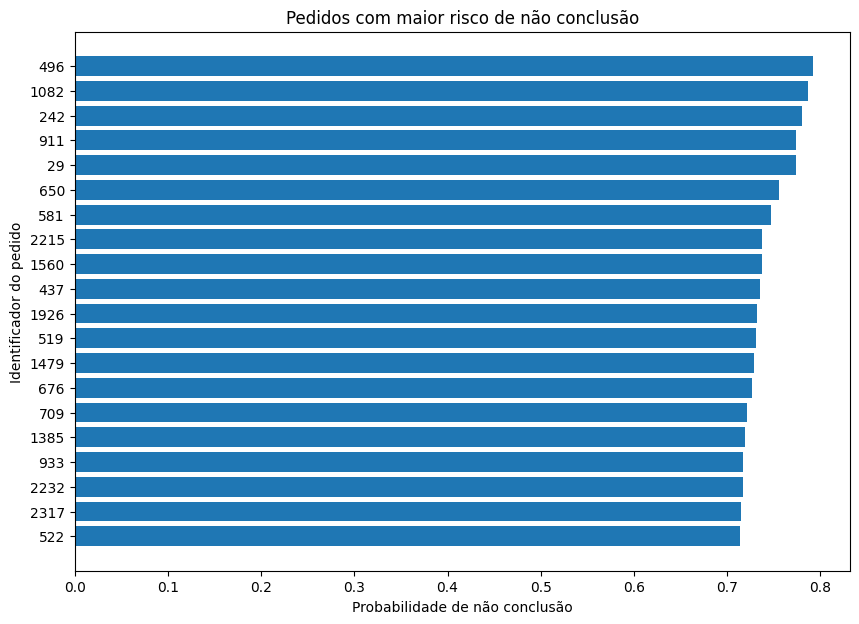

In [55]:

pedidos_grafico = pedidos_maior_risco.sort_values(
    "risco_nao_conclusao"
)

plt.figure(figsize=(10, 7))

plt.barh(
    pedidos_grafico["id_pedido"].astype(str),
    pedidos_grafico["risco_nao_conclusao"]
)

plt.title("Pedidos com maior risco de não conclusão")
plt.xlabel("Probabilidade de não conclusão")
plt.ylabel("Identificador do pedido")
plt.show()


# 27. Risco médio por canal

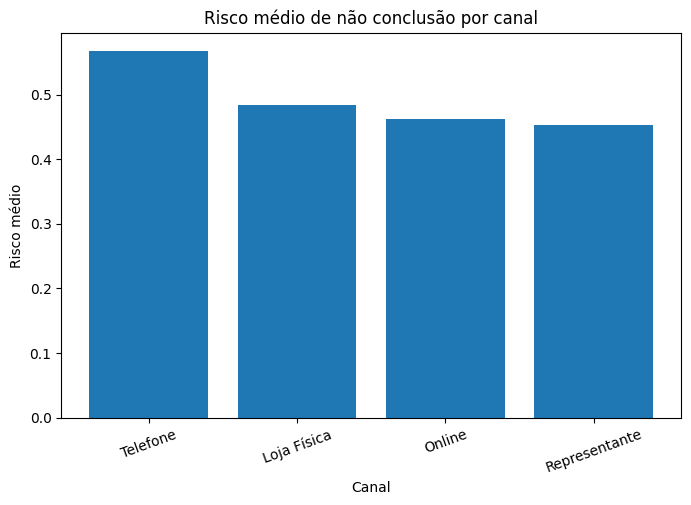

In [57]:
risco_por_canal = (
    base_resultado
    .groupby("canal", as_index=False)
    .agg(
        risco_medio=("risco_nao_conclusao", "mean"),
        quantidade_pedidos=("id_pedido", "count")
    )
    .sort_values(
        "risco_medio",
        ascending=False
    )
)

risco_por_canal
plt.figure(figsize=(8, 5))

plt.bar(
    risco_por_canal["canal"],
    risco_por_canal["risco_medio"]
)

plt.title("Risco médio de não conclusão por canal")
plt.xlabel("Canal")
plt.ylabel("Risco médio")
plt.xticks(rotation=20)
plt.show()



#28. Risco médio por região

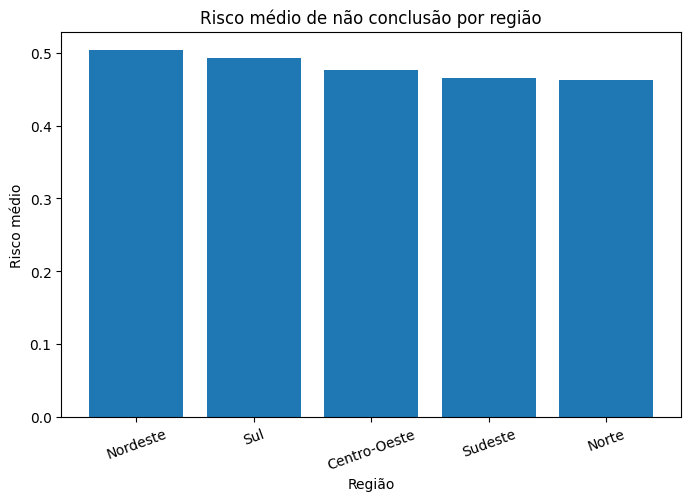

In [58]:

risco_por_regiao = (
    base_resultado
    .groupby("regiao", as_index=False)
    .agg(
        risco_medio=("risco_nao_conclusao", "mean"),
        quantidade_pedidos=("id_pedido", "count")
    )
    .sort_values(
        "risco_medio",
        ascending=False
    )
)

risco_por_regiao
plt.figure(figsize=(8, 5))

plt.bar(
    risco_por_regiao["regiao"],
    risco_por_regiao["risco_medio"]
)

plt.title("Risco médio de não conclusão por região")
plt.xlabel("Região")
plt.ylabel("Risco médio")
plt.xticks(rotation=20)
plt.show()



# 29. Risco médio por categoria

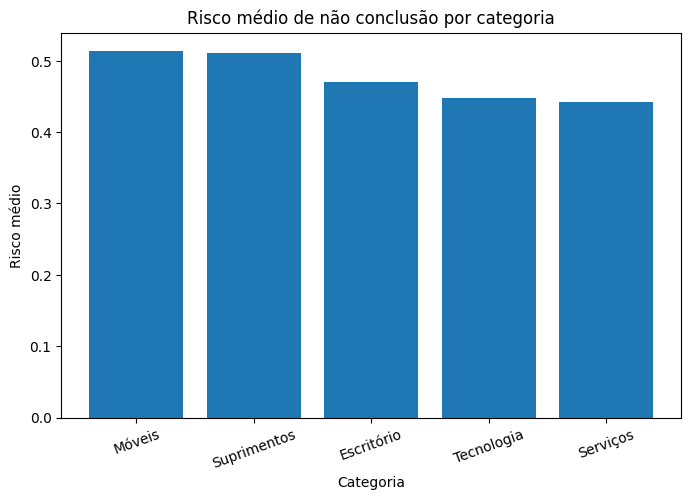

In [59]:

risco_por_categoria = (
    base_resultado
    .groupby("categoria", as_index=False)
    .agg(
        risco_medio=("risco_nao_conclusao", "mean"),
        quantidade_pedidos=("id_pedido", "count")
    )
    .sort_values(
        "risco_medio",
        ascending=False
    )
)

risco_por_categoria
plt.figure(figsize=(8, 5))

plt.bar(
    risco_por_categoria["categoria"],
    risco_por_categoria["risco_medio"]
)

plt.title("Risco médio de não conclusão por categoria")
plt.xlabel("Categoria")
plt.ylabel("Risco médio")
plt.xticks(rotation=20)
plt.show()


# 30. Resumo das métricas do modelo


In [60]:

metricas_modelo = pd.DataFrame({
    "metrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-score",
        "ROC AUC"
    ],
    "valor": [
        acuracia,
        precisao,
        recall,
        f1,
        auc
    ]
})

metricas_modelo["valor"] = metricas_modelo["valor"].round(4)

metricas_modelo



,metrica,valor
0,Acurácia,0.5267
1,Precisão,0.8771
2,Recall,0.5393
3,F1-score,0.6679
4,ROC AUC,0.4876


# 31. Exportação das métricas e análises

In [62]:


metricas_modelo.to_csv(
    "/content/metricas_modelo.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

importancia_variaveis.to_csv(
    "/content/importancia_variaveis.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

risco_por_canal.to_csv(
    "/content/risco_por_canal.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

risco_por_regiao.to_csv(
    "/content/risco_por_regiao.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

risco_por_categoria.to_csv(
    "/content/risco_por_categoria.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivos exportados com sucesso.")


Arquivos exportados com sucesso.



# 32. Exportação do modelo treinado

Esta etapa salva o pipeline completo, incluindo o tratamento dos dados e o modelo.


In [61]:

import joblib

In [ ]:


joblib.dump(
    pipeline_modelo,
    "/content/modelo_risco_pedidos.pkl"
)

print("Modelo salvo com sucesso.")



# 33. Exemplo de previsão para um novo pedido

In [ ]:

novo_pedido = pd.DataFrame({
    "mes": [6],
    "regiao": ["Sudeste"],
    "categoria": ["Tecnologia"],
    "produto": ["Notebook"],
    "canal": ["Online"],
    "vendedor": ["Vendedor 1"],
    "quantidade": [3],
    "preco_unitario": [2500.00],
    "receita_bruta": [7500.00]
})

probabilidade_conclusao = pipeline_modelo.predict_proba(
    novo_pedido
)[0, 1]

risco_nao_conclusao = 1 - probabilidade_conclusao

print(
    "Probabilidade de conclusão:",
    round(probabilidade_conclusao, 4)
)

print(
    "Risco de não conclusão:",
    round(risco_nao_conclusao, 4)
)

print(
    "Classificação do risco:",
    classificar_risco(risco_nao_conclusao)
)
#34. Consideração sobre os resultados
print(
    """
O modelo foi desenvolvido para identificar pedidos com maior risco de
cancelamento ou devolução.

Como os dados utilizados são fictícios e o status dos pedidos foi gerado
de forma aleatória, o modelo pode apresentar baixo poder de diferenciação.

Em um cenário real, o desempenho dependeria da existência de padrões entre
as características dos pedidos e seus resultados finais, porém, avalio como satisfatório o resultado obtido, considerando a natureza aleatória dos dados.
"""
)

Probabilidade de conclusão: 0.3581
Risco de não conclusão: 0.6419
Classificação do risco: Médio

O modelo foi desenvolvido para identificar pedidos com maior risco de
cancelamento ou devolução.

Como os dados utilizados são fictícios e o status dos pedidos foi gerado
de forma aleatória, o modelo pode apresentar baixo poder de diferenciação.

Em um cenário real, o desempenho dependeria da existência de padrões entre
as características dos pedidos e seus resultados finais.

